## Frame Extraction using OpenCV
- [x] Download sample video
- [x] Get the frames from the video
- [x] For each frame decide if it is valid based on animal movement and MSE similarity score

In [36]:
import os
import cv2
import numpy as np
import pandas as pd
from pexelsapi.pexels import Pexels
import matplotlib.pyplot as plt

In [4]:
PEXELS_KEY = "fdmnaf3q0usOwaMzOIU0FWjE6CEgMvRYSfEEjywCn32H0c4cZSLN2PrI"
api = Pexels(PEXELS_KEY)

search_results = api.search_videos(query="koala", orientation="landscape", size="large")
search_results

{'page': 1,
 'per_page': 15,
 'videos': [{'id': 14915376,
   'width': 3840,
   'height': 2160,
   'duration': 30,
   'full_res': None,
   'tags': [],
   'url': 'https://www.pexels.com/video/a-sleepy-koala-on-a-tree-branch-14915376/',
   'image': 'https://images.pexels.com/videos/14915376/bear-koala-koala-bear-nature-14915376.jpeg?auto=compress&cs=tinysrgb&fit=crop&h=630&w=1200',
   'avg_color': None,
   'user': {'id': 359553279,
    'name': 'The4KTravelChannel Travel',
    'url': 'https://www.pexels.com/@the4ktravelchannel-travel-359553279'},
   'video_files': [{'id': 11335612,
     'quality': 'sd',
     'file_type': 'video/mp4',
     'width': 426,
     'height': 240,
     'fps': 29.97,
     'link': 'https://videos.pexels.com/video-files/14915376/14915376-sd_426_240_30fps.mp4',
     'size': 1991392},
    {'id': 11335648,
     'quality': 'uhd',
     'file_type': 'video/mp4',
     'width': 2560,
     'height': 1440,
     'fps': 29.97,
     'link': 'https://videos.pexels.com/video-files/1

In [5]:
import requests

def download_video(url, save_path):
  try:
    response = requests.get(url, stream=True)
    response.raise_for_status()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    with open(save_path, "wb") as f:
      for chunk in response.iter_content(chunk_size=8192):
        if chunk:
          f.write(chunk)
    print(f"Video downloaded successfully to {save_path}")

  except Exception as e:
    print(f"Video could not be loaded: {e}")


video_1_url = search_results["videos"][0]["video_files"][5]["link"]
save_path_1 = "videos/koala_video1.mp4"

search_results = api.search_videos(query="colibri", orientation="landscape", size="large")
video_2_url = search_results["videos"][0]["video_files"][5]["link"]
save_path_2 = "videos/colibri_video1.mp4"

download_video(video_1_url, save_path_1)
download_video(video_2_url, save_path_2)

Video downloaded successfully to videos/koala_video1.mp4
Video downloaded successfully to videos/colibri_video1.mp4


In [6]:
def image_mse(last_image, new_image):
  mse_matrix = (new_image.astype("float") - last_image.astype("float"))**2
  pixel_count = mse_matrix.shape[0] * mse_matrix.shape[1] * mse_matrix.shape[2]
  mse = np.sum(mse_matrix.reshape(-1)) / (pixel_count)
  return mse


image1 = np.ones((24, 24, 3))
image2 = np.random.random((24, 24, 3))

image_mse(image1, image2)

np.float64(0.326750813945049)

## SSIM similarity of images calculation
While MSE is highly sensitive to global changes like lightning ssim focuses motre on animal features

In [29]:
from skimage.metrics import structural_similarity as ssim

def calculate_ssim_score(image1, image2, threshold=0.82):
    gray_1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
    gray_2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)
    ssim_score = ssim(gray_1, gray_2)
    #print(ssim_score)
    #return ssim_score > threshold
    return ssim_score

In [27]:
# Get sharpness score by computing laplasian variance

def get_sharpness_score(image):
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    score = cv2.Laplacian(gray_image, cv2.CV_64F).var() 
    # 0-50 Blurry image, 50-300 Normal sharpness 300+ Sharp 
    return score

In [68]:
def calculate_frame_metrics(frame:np.array, last_frame, back_sub):
    """Calculates  motion ratio score, frame similarity SSIM score, and sharpness score """
    mask = back_sub.apply(frame)
    nonzero_count = cv2.countNonZero(mask)
    motion_ratio_score = nonzero_count / (360*640)

    # Use methods for ssim and sharpness scores
    ssim_score = calculate_ssim_score(frame, last_frame)
    sharpness_score = get_sharpness_score(frame)

    return (motion_ratio_score, ssim_score, sharpness_score)
    

In [69]:
def calculate_video_scores(video_path):
    """Calculates motion, ssim and sharpness score for each videoframe"""

    scores_dict = {"motion_scores": [],
                   "ssim_scores": [],
                   "sharpness_scores": []}

    cap = cv2.VideoCapture(video_path)
    back_sub = cv2.createBackgroundSubtractorMOG2(history=100, varThreshold=50)
    last_frame = None
    
    while True:
        ret, frame = cap.read()
        if not ret: 
            break

        # 1. Resize for faster detection 
        small_frame = cv2.resize(frame, (640, 360))
        if last_frame is None:
          last_frame = small_frame
          continue
        
        motion_score, ssim_score, sharpness_score = calculate_frame_metrics(small_frame, 
                                                                            last_frame,
                                                                            back_sub)
        # Add the scores for the crrent videoframe to the result diSct
        scores_dict["motion_scores"].append(motion_score)
        scores_dict["ssim_scores"].append(ssim_score)
        scores_dict["sharpness_scores"].append(sharpness_score)

    cap.release()
    print("All metrics saved successflly")
    
    return scores_dict
        
scores_dict = calculate_video_scores("videos/colibri_video1.mp4")

All metrics saved successflly


Text(0.5, 1.0, 'Motion Scores distribution for colibri video')

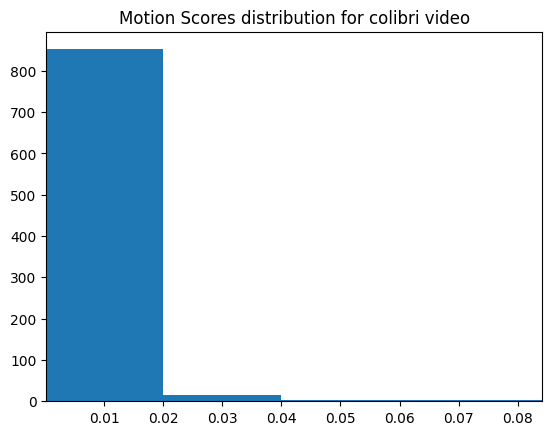

In [74]:
# Visualize metrics for the colibri video
data = scores_dict["motion_scores"]
plt.hist(data, bins=50)
plt.xlim(np.percentile(data, 2), np.percentile(data, 97))
plt.title("Motion Scores distribution for colibri video")

Text(0.5, 1.0, 'Sharpness Scores distribution for colibri video')

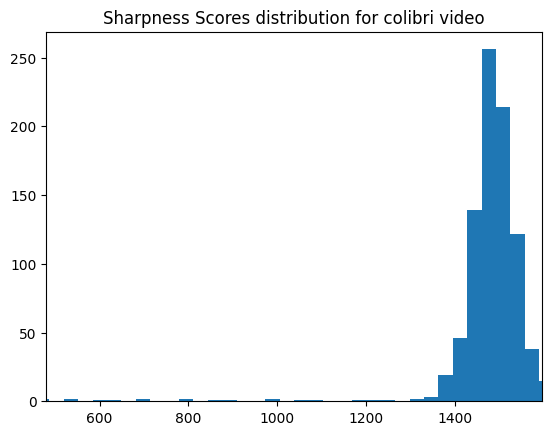

In [75]:
# Visualize metrics for the colibri video
data = scores_dict["sharpness_scores"]
plt.hist(data, bins=50)
plt.xlim(np.percentile(data, 3), np.percentile(data, 99))
plt.title("Sharpness Scores distribution for colibri video")

Text(0.5, 1.0, 'SSIM Scores distribution for colibri video')

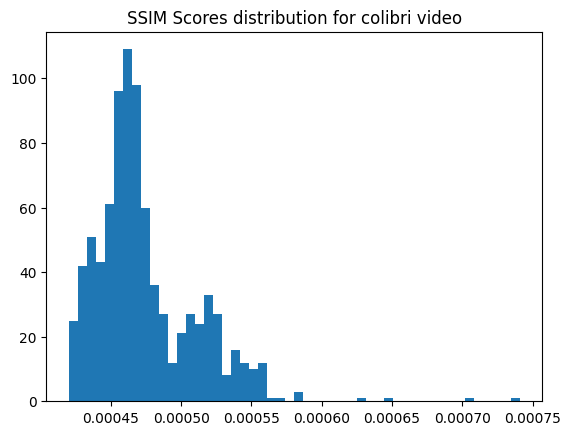

In [76]:
# Visualize metrics for the colibri video
plt.hist(sorted(scores_dict["ssim_scores"])[:-40], bins=50)
plt.title("SSIM Scores distribution for colibri video")

## Identify the best frames best on the calculated scores

In [ ]:
def calculate_weighted_score(scores_dict):
    


In [ ]:
def pick_best_frames(scores_dict):


In [ ]:
import cv2
import os

mse_values = []

colibri_frames_dir = "detected_frames/colibri"
koala_frames_dir = "detected_frames/koala"

def save_frames_to_disk(video_path, output_folder="detected_frames"):
    os.makedirs(output_folder, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    # Create background subtractor object
    back_sub = cv2.createBackgroundSubtractorMOG2(history=100, varThreshold=50)
    
    frame_idx = 0
    saved_count = 0
    last_frame = None

    while True:
        ret, frame = cap.read()
        if not ret: break
        
        # Process only every 5th frame
        if frame_idx % 5 != 0:
            frame_idx += 1
            continue
        
        # 1. Resize for detection 
        small_frame = cv2.resize(frame, (640, 360))
        
        # 3. Save to disk if motion is found (instead of appending to a list)
        if last_frame is None:
          last_frame = small_frame
          frame_idx += 1
          continue

     
        motion_score, ssim_score, sharpness_score = calculate_frame_metrics(small_frame, last_frame, back_sub)
        
        if motion_score > 0.04 and ssim_score < 0.8 and sharpness_score > 300: # 0.3% motion and 700 mse threshold
            file_path = os.path.join(output_folder, f"frame_{frame_idx:04d}.jpg")
            cv2.imwrite(file_path, frame) # Save the original high-quality frame
            last_frame = small_frame
            saved_count += 1
            print(f"Frame {saved_count} saved")
            
        frame_idx += 1
        
        # Periodically clear output
        if frame_idx % 500 == 0:
            print(f"Processed {frame_idx} frames... saved {saved_count}")

    cap.release()
    print(f"Done! Check the {output_folder} folder.")

save_frames_to_disk(save_path_1, koala_frames_dir)

Frame 1 saved
Frame 2 saved
Frame 3 saved
Frame 4 saved
Processed 500 frames... saved 4
Done! Check the detected_frames/koala folder.


In [ ]:
save_frames_to_disk(save_path_2, colibri_frames_dir)

0.0007859907685011787
Frame 1 saved
0.9806908931715942
0.970292591146906
0.9609502637435435
0.949356628461433
0.9460578394758243
0.9461953475758396
0.939731758454734
0.9372779204322806
Processed 500 frames... saved 1
0.7725793986004948
Frame 2 saved
0.9755277248531475
0.9654211681678974
0.9575308383322303
0.9414554628714197
0.9280455185944535
0.9060269192238839
0.8830567301846846
0.8526305674188084
0.8190946975749932
0.7752558506651764
Frame 3 saved
0.9867226787823219
0.9656517181086132
0.9399857252576317
0.8943141813706484
0.8363942379394521
0.7496107651521284
Frame 4 saved
0.9764153791654374
0.9019059777753018
0.7786935956126265
Frame 5 saved
0.8942389166173496
0.5530859466052269
Frame 6 saved
Done! Check the detected_frames/colibri folder.


In [25]:
remove = True

if remove:
  for f in os.listdir(koala_frames_dir):
    os.remove(os.path.join(koala_frames_dir, f))
